# One-at-a-time incremental stitching

This notebook stitches a set of images incrementally, one image at a time (lexicographic order). It detects features once for all images, then merges images sequentially by matching the next image to the cumulative feature bank, estimating a homography, warping and blending, and merging feature sets while deduplicating matched common features. This avoids re-running feature detection on already-merged content. Intermediate visualizations are shown at each step.

Notes:
- Images are ordered by filename (lexicographically).
- Features are detected once per image up front.
- At each step, we match current image descriptors to the combined feature bank, estimate Homography (RANSAC), warp and blend to the current mosaic, and merge features (transforming them into the mosaic base frame, deduplicating within a pixel threshold so matched common features are counted only once).
- Resizing keeps the spirit of the tutorial (medium/low style) but NEVER upscales. Small images like 640x480 are kept at native resolution.
- Visualizations: keypoints (green dots), matches (lines), and the growing mosaic with cumulative keypoints.


In [53]:
import os
from pathlib import Path
from typing import List, Tuple
import time

import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

from stitching.feature_detector import FeatureDetector
from stitching.feature_matcher import FeatureMatcher
from stitching.camera_estimator import CameraEstimator
from stitching.camera_adjuster import CameraAdjuster
from stitching.camera_wave_corrector import WaveCorrector
from stitching.warper import Warper
from stitching.seam_finder import SeamFinder
from stitching.exposure_error_compensator import ExposureErrorCompensator
from stitching.blender import Blender
from stitching.subsetter import Subsetter

np.set_printoptions(suppress=True, linewidth=140)

def plot_image(img, figsize=(6,6), title=None):
    fig, ax = plt.subplots(figsize=figsize)
    if img.ndim == 2:
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    if title:
        ax.set_title(title)
    ax.axis('off')
    plt.show()

def plot_images(imgs, titles=None, figsize=(16,6)):
    n = len(imgs)
    fig, axs = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axs = [axs]
    for i, img in enumerate(imgs):
        if img.ndim == 2:
            axs[i].imshow(img, cmap='gray')
        else:
            axs[i].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        if titles is not None:
            axs[i].set_title(titles[i])
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

def draw_keypoints(img, kps, color=(0,255,0)):
    out = img.copy()
    flags = cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    return cv.drawKeypoints(img, kps, None, color=color, flags=flags)

def to_keypoints_from_xy(points: np.ndarray, size=3):
    # points: Nx2 float32
    return [cv.KeyPoint(float(x), float(y), size) for x, y in points]

def concat_h(img1, img2):
    h = max(img1.shape[0], img2.shape[0])
    w = img1.shape[1] + img2.shape[1]
    out = np.zeros((h, w, 3), dtype=np.uint8)
    out[:img1.shape[0], :img1.shape[1]] = img1
    out[:img2.shape[0], img1.shape[1]:img1.shape[1]+img2.shape[1]] = img2
    return out

def show_matches(imgA, kpsA, imgB, kpsB, matches, inlier_mask=None, max_draw=200, figsize=(16,8), title='Matches'):
    # Optionally limit number of matches drawn for speed
    draw_matches = matches
    if len(draw_matches) > max_draw:
        draw_matches = draw_matches[:max_draw]
    flags = cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    if inlier_mask is not None:
        # Only draw inliers
        inliers = [m for m, keep in zip(draw_matches, inlier_mask[:len(draw_matches)]) if keep]
        draw_matches = inliers
    vis = cv.drawMatches(imgA, kpsA, imgB, kpsB, draw_matches, None, matchColor=(0,255,0), flags=flags)
    plot_image(vis, figsize=figsize, title=title)



## Configuration and image listing

- Set `IMAGE_DIR` to the directory containing your images.
- Images are filtered by extension and sorted lexicographically.
- You can also set `IMAGE_PATHS` manually to override directory listing.

In [54]:
# Directory of input images (lexicographically ordered)
IMAGE_DIR = "final/data/calibration_run"  # change if needed
EXTS = (".jpg", ".jpeg", ".png", ".bmp")

# Optionally override with explicit list. If not empty, these are used instead of IMAGE_DIR.
IMAGE_PATHS: List[str] = []

def list_images_sorted(image_dir: str) -> List[str]:
    files = [str(Path(image_dir) / f) for f in os.listdir(image_dir)
             if f.lower().endswith(EXTS) and not f.startswith('.')]
    files.sort()
    return files

if IMAGE_PATHS:
    imgs_list = [str(Path(p)) for p in IMAGE_PATHS]
else:
    imgs_list = list_images_sorted(IMAGE_DIR)

print(f"Found {len(imgs_list)} images")
for i, p in enumerate(imgs_list[::2]):
    idx = i*2
    next_idx = idx + 1
    print(" •", Path(p).name, "\t •", Path(imgs_list[next_idx]).name if next_idx < len(imgs_list) else "")

assert len(imgs_list) >= 2, "Need at least two images to stitch"

# Load color images (BGR as cv default)
orig_imgs = []
for p in imgs_list:
    im = cv.imread(p, cv.IMREAD_COLOR)
    if im is None:
        raise ValueError(f"Failed to read image: {p}")
    orig_imgs.append(im)

print("Loaded shapes:")
for i, im in enumerate(orig_imgs[::3]):
    h, w = im.shape[:2]
    h2, w2 = orig_imgs[i+1].shape[:2] if i+1 < len(orig_imgs) else (0,0)
    h3, w3 = orig_imgs[i+2].shape[:2] if i+2 < len(orig_imgs) else (0,0)
    print(f"  Img{i+1}: {w}x{h}",f"  Img{i+2}: {w2}x{h2}" if h2 else "", f"  Img{i+3}: {w3}x{h3}" if h3 else "")

Found 42 images
 • esp_1_1757157562687.jpg 	 • esp_1_1757157562915.jpg
 • esp_1_1757157563438.jpg 	 • esp_1_1757157563597.jpg
 • esp_1_1757157564148.jpg 	 • esp_1_1757157564409.jpg
 • esp_1_1757157564750.jpg 	 • esp_1_1757157565262.jpg
 • esp_1_1757157565639.jpg 	 • esp_1_1757157565970.jpg
 • esp_1_1757157566485.jpg 	 • esp_1_1757157566887.jpg
 • esp_2_1757157562695.jpg 	 • esp_2_1757157562819.jpg
 • esp_2_1757157563430.jpg 	 • esp_2_1757157563716.jpg
 • esp_2_1757157564040.jpg 	 • esp_2_1757157564822.jpg
 • esp_2_1757157565145.jpg 	 • esp_2_1757157565437.jpg
 • esp_2_1757157566154.jpg 	 • esp_2_1757157566670.jpg
 • esp_2_1757157566976.jpg 	 • esp_2_1757157567203.jpg
 • esp_3_1757157562669.jpg 	 • esp_3_1757157562983.jpg
 • esp_3_1757157563605.jpg 	 • esp_3_1757157563831.jpg
 • esp_3_1757157564741.jpg 	 • esp_3_1757157565239.jpg
 • esp_3_1757157565543.jpg 	 • esp_4_1757157562586.jpg
 • esp_4_1757157563076.jpg 	 • esp_4_1757157563116.jpg
 • esp_4_1757157563805.jpg 	 • esp_4_175715756402

## Safe resizing (no upscaling)

We use a megapixel-based target similar to the tutorial, but we never upscale. If an image is smaller than the target, we keep it as-is. This preserves small images (e.g., 640x480).

Work sizes:
  Img1: 800x600
  Img2: 800x600
  Img3: 800x600
  Img4: 800x600
  Img5: 800x600

  Img1: 800x600
  Img2: 800x600
  Img3: 800x600
  Img4: 800x600
  Img5: 800x600


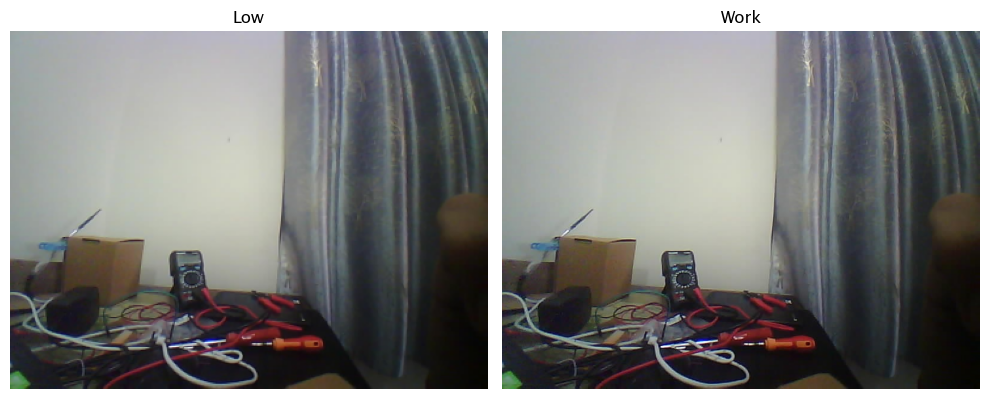

In [55]:
WORK_MPIX = 0.6  # ~0.6 MP like medium in the tutorial; set to 0 or negative to skip resizing
LOW_MPIX = 0.1   # used only for optional quick previews

def resize_to_megapix(img: np.ndarray, target_mpix: float, allow_upscale: bool = False) -> np.ndarray:
    if target_mpix is None or target_mpix <= 0:
        return img
    h, w = img.shape[:2]
    cur_mpix = (w * h) / 1e6
    if cur_mpix <= 0:
        return img
    scale = np.sqrt(target_mpix / cur_mpix)
    if scale >= 1.0 and not allow_upscale:
        return img
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    interp = cv.INTER_AREA if scale < 1.0 else cv.INTER_LINEAR
    return cv.resize(img, (new_w, new_h), interpolation=interp)

work_imgs = [resize_to_megapix(im, WORK_MPIX, allow_upscale=False) for im in orig_imgs]
low_imgs = [resize_to_megapix(im, LOW_MPIX, allow_upscale=False) for im in orig_imgs]

print("Work sizes:")
for i, im in enumerate(work_imgs[:5]):
    h, w = im.shape[:2]
    print(f"  Img{i+1}: {w}x{h}")

plot_images([low_imgs[0], work_imgs[0]], titles=["Low","Work"], figsize=(10,5))

## Feature detection (once per image)

We use ORB (fast) with a relatively high feature count. You can switch to SIFT/AKAZE/BRISK if needed (requires contrib / nonfree where applicable).

Image 1: 2367 keypoints, desc shape (2367, 32)
Image 2: 2002 keypoints, desc shape (2002, 32)
Image 3: 2381 keypoints, desc shape (2381, 32)
Image 4: 1254 keypoints, desc shape (1254, 32)
Image 5: 2128 keypoints, desc shape (2128, 32)
Image 6: 2965 keypoints, desc shape (2965, 32)
Image 7: 3040 keypoints, desc shape (3040, 32)
Image 8: 3032 keypoints, desc shape (3032, 32)
Image 9: 3119 keypoints, desc shape (3119, 32)
Image 10: 3277 keypoints, desc shape (3277, 32)
Image 11: 3222 keypoints, desc shape (3222, 32)
Image 12: 2812 keypoints, desc shape (2812, 32)
Image 13: 3316 keypoints, desc shape (3316, 32)
Image 14: 3105 keypoints, desc shape (3105, 32)
Image 15: 3010 keypoints, desc shape (3010, 32)
Image 16: 1873 keypoints, desc shape (1873, 32)
Image 17: 2778 keypoints, desc shape (2778, 32)
Image 18: 2897 keypoints, desc shape (2897, 32)
Image 19: 2714 keypoints, desc shape (2714, 32)
Image 20: 2859 keypoints, desc shape (2859, 32)
Image 21: 2741 keypoints, desc shape (2741, 32)
I

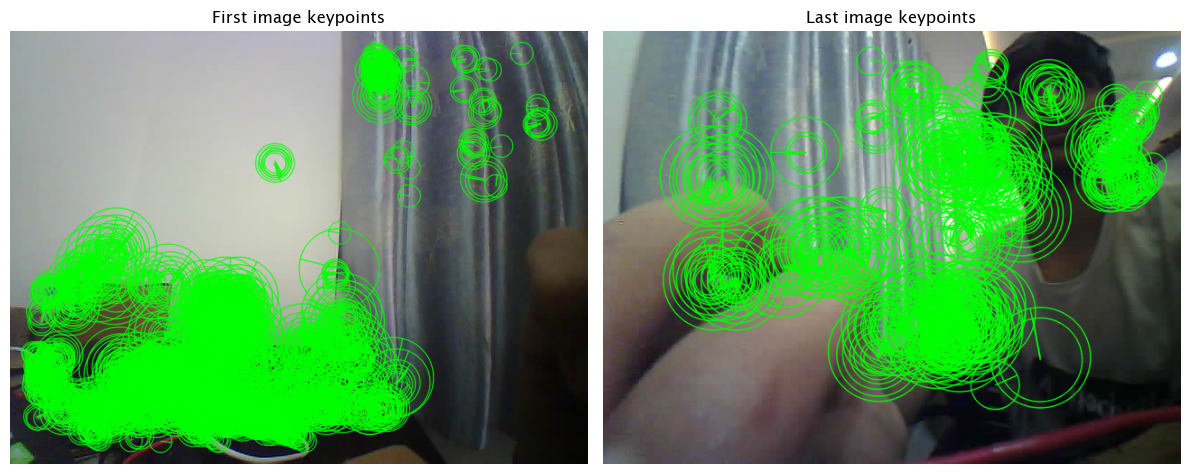

In [56]:
DETECTOR = "orb"   # orb | brisk | akaze | sift (if available)
N_FEATURES = 5000

def create_detector(kind: str, nfeatures: int):
    kind = kind.lower()
    if kind == 'orb':
        return cv.ORB_create(nfeatures=nfeatures)
    if kind == 'brisk':
        return cv.BRISK_create()
    if kind == 'akaze':
        return cv.AKAZE_create()
    if kind == 'sift':
        # Requires xfeatures2d / nonfree depending on build
        try:
            return cv.SIFT_create(nfeatures=nfeatures)
        except Exception as e:
            raise RuntimeError("SIFT not available in this OpenCV build") from e
    raise ValueError(f"Unknown detector: {kind}")

def fallback_feature_detection(imgA, imgB, detector_kind='orb', nfeatures=10000):
    detector = create_detector(detector_kind, nfeatures)
    kpsA, descA = detector.detectAndCompute(imgA, None)
    kpsB, descB = detector.detectAndCompute(imgB, None)

    # Ensure descriptors are valid
    if descA is None or descA.size == 0:
        descA = np.zeros((0, 32 if detector_kind.lower() != 'sift' else 128), dtype=np.uint8 if detector_kind.lower() != 'sift' else np.float32)
    if descB is None or descB.size == 0:
        descB = np.zeros((0, 32 if detector_kind.lower() != 'sift' else 128), dtype=np.uint8 if detector_kind.lower() != 'sift' else np.float32)

    return kpsA, descA, kpsB, descB

detector = create_detector(DETECTOR, N_FEATURES)

all_kps: List[List[cv.KeyPoint]] = []
all_descs: List[np.ndarray] = []

for i, im in enumerate(work_imgs):
    kps, desc = detector.detectAndCompute(im, None)
    if desc is None:
        desc = np.zeros((0, 32), dtype=np.uint8)
    all_kps.append(kps)
    all_descs.append(desc)
    print(f"Image {i+1}: {len(kps)} keypoints, desc shape {desc.shape}")

plot_images([
    draw_keypoints(work_imgs[0], all_kps[0]),
    draw_keypoints(work_imgs[-1], all_kps[-1])
], titles=["First image keypoints","Last image keypoints"], figsize=(12,5))

# Stitching library features for camera estimation + spherical warping

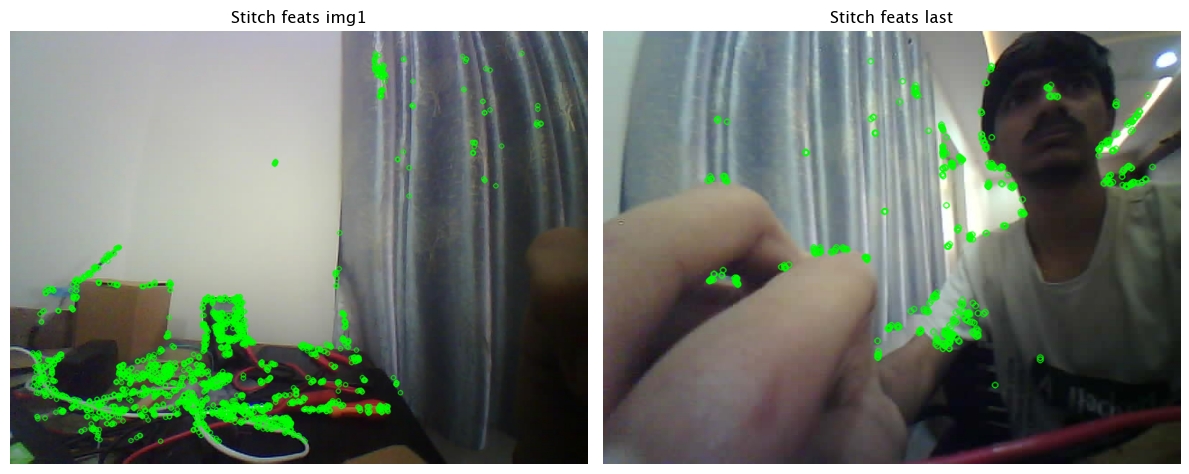

In [57]:
stitch_finder = FeatureDetector(detector=DETECTOR, nfeatures=N_FEATURES)
features_stitch = [stitch_finder.detect_features(img) for img in work_imgs]

# Optional sanity check visualization

k0 = stitch_finder.draw_keypoints(work_imgs[0], features_stitch[0])
k1 = stitch_finder.draw_keypoints(work_imgs[-1], features_stitch[-1])
plot_images([k0, k1], titles=["Stitch feats img1", "Stitch feats last"], figsize=(12, 5))

# Spherical warping + camera estimation incremental pipeline (no upscaling; detect once)

USE_SPHERICAL = False  # Set True to run automatic loop; manual step-by-step controls are provided below.

In [58]:
if USE_SPHERICAL:
    print("Running spherical incremental pipeline with camera estimation...")
    matcher = FeatureMatcher(matcher_type="homography", range_width=1)
    camera_estimator = CameraEstimator()
    camera_adjuster = CameraAdjuster()
    wave_corrector = WaveCorrector()
    warper = Warper("spherical")
    # explicit spherical
    seam_finder = SeamFinder()
    compensator = ExposureErrorCompensator()

    # Start with first image; we will rebuild panorama each step with 0..i subset
    panorama = work_imgs[0].copy()

    # Norm for pairwise visualization (cv BF): SIFT->L2; others->Hamming
    norm = cv.NORM_L2 if DETECTOR.lower() == "sift" else cv.NORM_HAMMING

    for i in range(1, len(work_imgs)):
        print("\n" + "=" * 80)
        print(f"STEP {i}: merge image {i+1}/{len(work_imgs)} :: {Path(imgs_list[i]).name}")

        subset_imgs = work_imgs[:i+1]
        subset_feats = features_stitch[:i+1]

        # Pairwise match visualization between (i-1, i) using OpenCV features computed earlier
        kpsA, descA = all_kps[i-1], all_descs[i-1]
        kpsB, descB = all_kps[i],   all_descs[i]
        if descA is None or len(descA) == 0 or descB is None or len(descB) == 0:
            print("Insufficient pairwise descriptors for visualization; skipping pairwise plot.")
        else:
            bf = cv.BFMatcher(norm, crossCheck=True)  # norm = L2 for SIFT else Hamming
            pair_matches = bf.match(descA, descB)
            pair_matches = sorted(pair_matches, key=lambda m: m.distance)[:200]
            vis = cv.drawMatches(subset_imgs[i-1], kpsA, subset_imgs[i], kpsB, pair_matches, None, matchColor=(0, 255, 0))
            plot_image(vis, figsize=(16, 8), title=f"Pairwise matches (img {i} → {i+1})")

        # Camera estimation on current subset (estimate -> adjust -> wave-correct)
        matches = matcher.match_features(subset_feats)

        # Enforce connected match graph and robustness for adjuster
        subsetter = Subsetter(confidence_threshold=0.3)
        idxs = subsetter.get_indices_to_keep(subset_feats, matches)

        if len(idxs) == 0:
            print("No connected component found at this step; skipping image.")
            continue

        if len(idxs) != len(subset_feats):
            print(f"Dropping {len(subset_feats)-len(idxs)} unconnected images at this step:", idxs)
            subset_imgs = [subset_imgs[j] for j in idxs]
            subset_feats = [subset_feats[j] for j in idxs]
            matches = subsetter.subset_matches(matches, idxs)

        cameras = camera_estimator.estimate(subset_feats, matches)

        adjusted_ok = False
        for th in (0.3, 0.0):
            try:
                camera_adjuster = CameraAdjuster(confidence_threshold=th)
                cameras = camera_adjuster.adjust(subset_feats, matches, cameras)
                adjusted_ok = True
                break
            except Exception as e:
                print(f"Adjuster failed at confidence_threshold={th}: {e}")

        if not adjusted_ok:
            print("Camera adjusting failed even after fallback; skipping this image.")
            continue

        cameras = wave_corrector.correct(cameras)

        # Set warper scale (use median focal internally)
        warper.set_scale(cameras)
        aspect = 1.0  # estimating & warping at same resolution
        sizes_in = [(img.shape[1], img.shape[0]) for img in subset_imgs]

        # Warp images and masks (spherical)
        warped_imgs = list(warper.warp_images(subset_imgs, cameras, aspect))
        warped_masks = list(warper.create_and_warp_masks(sizes_in, cameras, aspect))
        corners, sizes_out = warper.warp_rois(sizes_in, cameras, aspect)

        # Seams
        seam_masks = seam_finder.find(warped_imgs, corners, warped_masks)

        # Exposure compensation (optional but helps blending)
        compensator.feed(corners, warped_imgs, warped_masks)
        compensated_imgs = [
            compensator.apply(idx, corner, img, mask)
            for idx, (img, mask, corner) in enumerate(zip(warped_imgs, warped_masks, corners))
        ]

        # Blend to produce the current panorama
        blender = Blender()
        blender.prepare(corners, sizes_out)
        for img, mask, corner in zip(compensated_imgs, seam_masks, corners):
            blender.feed(img, mask, corner)
        panorama, _ = blender.blend()

        plot_image(panorama, figsize=(10, 10), title=f"Spherical mosaic after img {i+1}")

    # Save final spherical panorama
    out_path = "one_at_a_time_spherical.png"
    cv.imwrite(out_path, panorama)
    print(f"Saved spherical panorama: {out_path}")

## Manual, step-by-step spherical pipeline (debug-friendly)

You can run these cells one-by-one to merge the next image, inspect variables,
and print confidence scores. Set CUR_I to the index of the "next" image to include (0-based).
The subset used is work_imgs[:CUR_I+1] in lexicographic order.

In [59]:
# Step controls and runtime options
CUR_I = 0  # 1..len(work_imgs)-1 (subset will be images [0..CUR_I])
RANGE_WIDTH = 1  # match only neighbors for stability
CONF_THRESH_MATCHES = 0.3  # subset connectivity threshold
ADJ_THRESHOLDS = (0.3, 0.0)  # fallback thresholds for CameraAdjuster
RUN_SEAMS = True
RUN_EXPOSURE_COMP = True

# Shared debug state dict, populated by the following cells
STATE = {}

## Run the next steps again and again

In [141]:
CUR_I += 1

Confidence matrix shape: (16, 16)
Neighbor confidences (k=1 diagonal): [2.963 2.243 2.283 2.258 0.    2.814 2.812 2.83  2.924 2.827 2.897 0.52  0.    2.299 2.305]
Min neighbor confidence: 0.0
Confidence for neighbor pair (14,15): 2.305


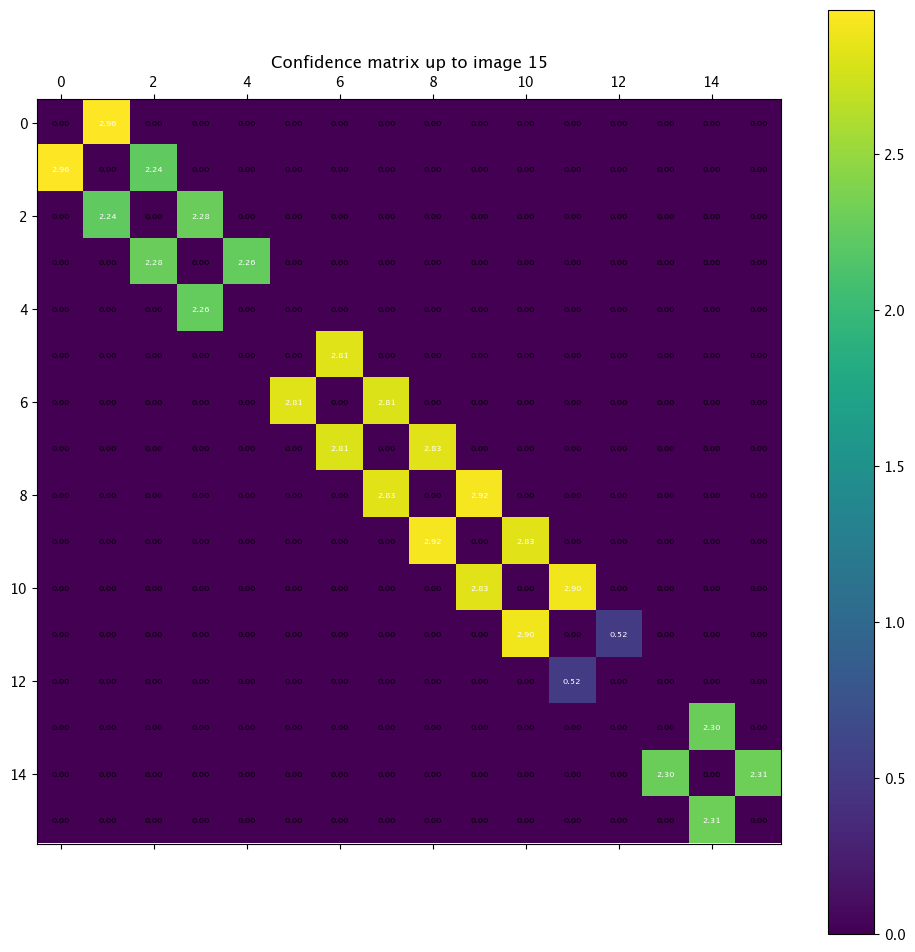

In [144]:
# 1) Compute pairwise matches for the current subset and show confidence matrix
matcher_debug = FeatureMatcher(matcher_type="homography", range_width=RANGE_WIDTH)

subset_imgs = work_imgs[:CUR_I+1]
subset_feats = features_stitch[:CUR_I+1]

matches_dbg = matcher_debug.match_features(subset_feats)
conf_matrix = matcher_debug.get_confidence_matrix(matches_dbg)
# print("conf_matrix after get_confidence_matrix:", conf_matrix)

print("Confidence matrix shape:", conf_matrix.shape)
np.set_printoptions(precision=3, suppress=True, linewidth=160)
# print(conf_matrix)

# Neighbor confidences (k=1 diagonal) – useful for sequential merges
neighbor_conf = None
if conf_matrix.shape[0] > 1:
    neighbor_conf = np.diag(conf_matrix, k=1)
    print("Neighbor confidences (k=1 diagonal):", neighbor_conf)
    print("Min neighbor confidence:", float(np.min(neighbor_conf)))

# --- Fallback if the latest neighbor has low confidence ---
if CUR_I >= 1:
    cur_conf = float(conf_matrix[CUR_I-1, CUR_I])
    print(f"Confidence for neighbor pair ({CUR_I-1},{CUR_I}): {cur_conf:.3f}")
    if cur_conf < 0.8:  # threshold for fallback, lowered to catch more cases
        print("Retrying...")
        # just try it again to be sure
        conf_matrix = matcher_debug.get_confidence_matrix(matches_dbg)
        time.sleep(0.01)
        # print("conf_matrix after get_confidence_matrix:", conf_matrix)

        print("Confidence matrix shape:", conf_matrix.shape)
        np.set_printoptions(precision=3, suppress=True, linewidth=160)
        # print(conf_matrix)

        # Neighbor confidences (k=1 diagonal) – useful for sequential merges
        neighbor_conf = None
        if conf_matrix.shape[0] > 1:
            neighbor_conf = np.diag(conf_matrix, k=1)
            print("Neighbor confidences (k=1 diagonal):", neighbor_conf)
            print("Min neighbor confidence:", float(np.min(neighbor_conf)))
        cur_conf = float(conf_matrix[CUR_I-1, CUR_I])
        print(f"Confidence for neighbor pair ({CUR_I-1},{CUR_I}): {cur_conf:.3f}")
        if cur_conf < 0.8:
            print(f"Low confidence detected for frame {CUR_I}. Running extensive fallback alignment...")

            imgA, imgB = subset_imgs[CUR_I-1], subset_imgs[CUR_I]
            grayA, grayB = cv.cvtColor(imgA, cv.COLOR_BGR2GRAY), cv.cvtColor(imgB, cv.COLOR_BGR2GRAY)

            # Re-detect features with higher count for better matching
            kpsA, descA, kpsB, descB = fallback_feature_detection(grayA, grayB, DETECTOR, nfeatures=10000)

            if (descA is not None and descA.shape[0] > 0 and descB is not None and descB.shape[0] > 0 and
                descA.shape[1] == descB.shape[1] and descA.dtype == descB.dtype):
                norm = cv.NORM_L2 if DETECTOR.lower() == "sift" else cv.NORM_HAMMING
                bf = cv.BFMatcher(norm, crossCheck=False)

                try:
                    # Use KNN for better matching with ratio test
                    knn_matches = bf.knnMatch(descA, descB, k=2)
                    good_matches = []
                    for m in knn_matches:
                        if len(m) == 2:
                            m1, m2 = m
                            if m1.distance < 0.75 * m2.distance:
                                good_matches.append(m1)
                        elif len(m) == 1:
                            good_matches.append(m[0])

                    if len(good_matches) >= 4:
                        ptsA = np.float32([kpsA[m.queryIdx].pt for m in good_matches])
                        ptsB = np.float32([kpsB[m.trainIdx].pt for m in good_matches])
                        H, inliers = cv.findHomography(ptsA, ptsB, cv.RANSAC, 5.0)
                        if H is not None and inliers.sum() >= 10:
                            print(f"Fallback homography succeeded with {inliers.sum()} inliers.")
                            # fabricate a MatchInfo-like object (minimal)
                            m = matches_dbg[CUR_I-1]
                            m.H = H
                            m.num_inliers = int(inliers.sum())
                            conf_matrix[CUR_I-1, CUR_I] = m.num_inliers / max(len(good_matches), 1)
                        else:
                            print("Homography fallback failed, trying ECC...")
                            warp_matrix = np.eye(3, 3, dtype=np.float32)
                            try:
                                cc, warp_matrix = cv.findTransformECC(
                                    grayA, grayB, warp_matrix, cv.MOTION_HOMOGRAPHY,
                                    criteria=(cv.TERM_CRITERIA_EPS | cv.TERM_CRITERIA_COUNT, 5000, 1e-6)
                                )
                                print(f"ECC fallback succeeded (cc={cc:.4f}).")
                                m = matches_dbg[CUR_I-1]
                                m.H = warp_matrix
                                m.num_inliers = 20  # fake count
                                conf_matrix[CUR_I-1, CUR_I] = 0.5  # assign mid confidence
                            except Exception as e:
                                print("ECC fallback also failed:", e)
                    else:
                        print("Not enough good matches after ratio test.")
                except Exception as e:
                    print(f"BFMatcher failed in fallback: {e}")
            else:
                print("Descriptors missing or incompatible, cannot run fallback.")

# Visualization of confidence matrix
fig, ax = plt.subplots(figsize=(min(12, 2+2*conf_matrix.shape[0]), min(12, 2+2*conf_matrix.shape[1])))
cax = ax.matshow(conf_matrix, interpolation='nearest')
fig.colorbar(cax)
for (i, j), z in np.ndenumerate(conf_matrix):
    ax.text(j, i, f"{z:0.2f}", ha='center', va='center', fontsize=6, color="white" if z > 0.5 else "black")
ax.set_title(f"Confidence matrix up to image {CUR_I}")
plt.show()

# Save interim to STATE
STATE.update({
    "subset_imgs": subset_imgs,
    "subset_feats": subset_feats,
    "matches_dbg": matches_dbg,
    "conf_matrix": conf_matrix,
})

In [145]:
# 2) Enforce connectivity and estimate/adjust cameras (with fallbacks). Inspect variables as needed.

subset_imgs = STATE["subset_imgs"]
subset_feats = STATE["subset_feats"]
matches_dbg = STATE["matches_dbg"]

# Keep largest connected component
subsetter = Subsetter(confidence_threshold=CONF_THRESH_MATCHES)
idxs = subsetter.get_indices_to_keep(subset_feats, matches_dbg)

print("Indices kept after connectivity check:", idxs)
if len(idxs) == 0:
    raise RuntimeError("No connected component found at this step; increase CONF_THRESH_MATCHES or check features.")

if len(idxs) != len(subset_feats):
    print(f"Dropping {len(subset_feats)-len(idxs)} unconnected images:", idxs)
    subset_imgs = [subset_imgs[j] for j in idxs]
    subset_feats = [subset_feats[j] for j in idxs]
    matches_dbg = subsetter.subset_matches(matches_dbg, idxs)

camera_estimator_dbg = CameraEstimator()
cameras_dbg = camera_estimator_dbg.estimate(subset_feats, matches_dbg)

# Try adjust with a couple of thresholds
adjusted_ok = False
last_error = None
for th in ADJ_THRESHOLDS:
    try:
        camera_adjuster_dbg = CameraAdjuster(confidence_threshold=th, adjuster="ray")
        cameras_dbg = camera_adjuster_dbg.adjust(subset_feats, matches_dbg, cameras_dbg)
        adjusted_ok = True
        print(f"CameraAdjuster (ray) succeeded at confidence_threshold={th}")
        break
    except Exception as e:
        last_error = e
        print(f"Ray adjuster failed at confidence_threshold={th}: {e}")

# Fallback reprojection adjuster
if not adjusted_ok:
    try:
        camera_adjuster_dbg = CameraAdjuster(confidence_threshold=1e-5, adjuster="reproj")
        cameras_dbg = camera_adjuster_dbg.adjust(subset_feats, matches_dbg, cameras_dbg)
        adjusted_ok = True
        print("CameraAdjuster (reproj) fallback succeeded")
    except Exception as e:
        last_error = e
        print(f"Reproj adjuster also failed: {e}")

# Final fallback
if not adjusted_ok:
    print(f"WARNING: Camera adjustment failed, keeping raw estimates. Last error: {last_error}")

wave_corrector_dbg = WaveCorrector()
cameras_dbg = wave_corrector_dbg.correct(cameras_dbg)

print(f"Estimated {len(cameras_dbg)} cameras")
for i, cam in enumerate(cameras_dbg):
    print(f"Cam {i}: focal={cam.focal:.2f}, ppx={cam.ppx:.1f}, ppy={cam.ppy:.1f}, aspect={cam.aspect:.4f}")

STATE.update({
    "subset_imgs": subset_imgs,
    "subset_feats": subset_feats,
    "matches_dbg": matches_dbg,
    "cameras_dbg": cameras_dbg,
})

Indices kept after connectivity check: [ 5  6  7  8  9 10 11 12]
Dropping 8 unconnected images: [ 5  6  7  8  9 10 11 12]
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  5 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  5 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  5 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  5 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had

Corners: [(-299, 108), (-336, 84), (-346, 83), (-357, 80), (-363, 80), (-372, 80), (-382, 80), (-810, 0)]
Sizes_out: [(684, 429), (733, 450), (735, 451), (744, 453), (744, 453), (746, 453), (747, 453), (915, 446)]


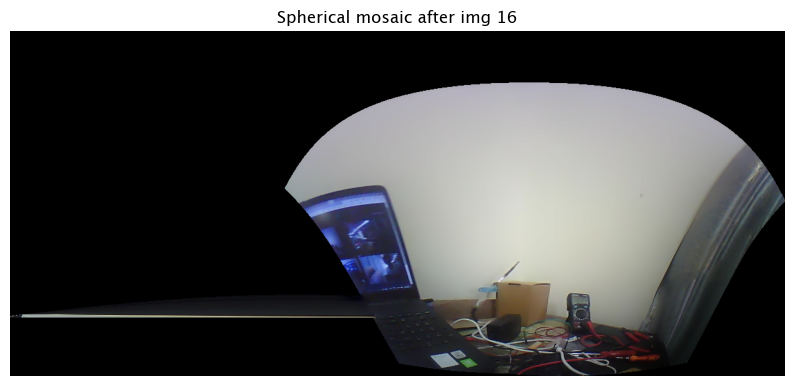

Saved spherical panorama for step 15: one_at_a_time_spherical_step_015.png


In [146]:
# 3) Warp (spherical), optional seams and exposure compensation, then blend. Inspect corners/sizes.

subset_imgs = STATE["subset_imgs"]
cameras_dbg = STATE["cameras_dbg"]

warper_dbg = Warper("spherical")
warper_dbg.set_scale(cameras_dbg)
aspect = 1.0  # working at the same resolution as features

sizes_in = [(img.shape[1], img.shape[0]) for img in subset_imgs]
warped_imgs = list(warper_dbg.warp_images(subset_imgs, cameras_dbg, aspect))
warped_masks = list(warper_dbg.create_and_warp_masks(sizes_in, cameras_dbg, aspect))
corners, sizes_out = warper_dbg.warp_rois(sizes_in, cameras_dbg, aspect)

print("Corners:", corners)
print("Sizes_out:", sizes_out)

# Seams
if RUN_SEAMS:
    seam_finder_dbg = SeamFinder()
    seam_masks = seam_finder_dbg.find(warped_imgs, corners, warped_masks)
else:
    seam_masks = warped_masks

# Exposure compensation
if RUN_EXPOSURE_COMP:
    compensator_dbg = ExposureErrorCompensator()
    compensator_dbg.feed(corners, warped_imgs, warped_masks)
    compensated_imgs = [
        compensator_dbg.apply(idx, corner, img, mask)
        for idx, (img, mask, corner) in enumerate(zip(warped_imgs, warped_masks, corners))
    ]
else:
    compensated_imgs = warped_imgs

# Blend
blender_dbg = Blender()
blender_dbg.prepare(corners, sizes_out)
for img, mask, corner in zip(compensated_imgs, seam_masks, corners):
    blender_dbg.feed(img, mask, corner)
panorama_dbg, _ = blender_dbg.blend()

plot_image(panorama_dbg, figsize=(10, 10), title=f"Spherical mosaic after img {CUR_I+1}")

out_path = f"one_at_a_time_spherical_step_{CUR_I:03d}.png"
cv.imwrite(out_path, panorama_dbg)
print(f"Saved spherical panorama for step {CUR_I}: {out_path}")

STATE.update({
    "warped_imgs": warped_imgs,
    "warped_masks": warped_masks,
    "corners": corners,
    "sizes_out": sizes_out,
    "seam_masks": seam_masks,
    "compensated_imgs": compensated_imgs,
    "panorama_dbg": panorama_dbg,
    "out_path": out_path,
})

##

In [139]:
print(CUR_I)

14


In [140]:
STATE_BKP = {}
STATE_BKP.update({
    "warped_imgs": warped_imgs,
    "warped_masks": warped_masks,
    "corners": corners,
    "sizes_out": sizes_out,
    "seam_masks": seam_masks,
    "compensated_imgs": compensated_imgs,
    "panorama_dbg": panorama_dbg,
    "out_path": out_path,
})

## Incremental matching, homography, warping, blending, and feature bank merging

At each step i:
- Match current image descriptors to the global feature bank (descriptors) accumulated so far.
- Estimate homography H (current → base frame) using RANSAC.
- Warp current image onto the existing canvas; if needed, expand the canvas with translation so all content stays within non-negative coordinates.
- Merge features: transform current keypoints by H into the base frame, then dedupe against the existing bank by a pixel threshold (so matched common features are counted only once). Append only new unique features and descriptors.
- Visualize: inlier matches, and the updated canvas with green dots for cumulative features.

In [ ]:
if USE_SPHERICAL:
    exit("This code need not run as spherical done above")
RATIO_TEST = 0.75
RANSAC_REPROJ_THRESH = 4.0
DEDUP_THRESH_PX = 3.0

def ratio_test_filter(knn_matches, ratio=0.75):
    good = []
    for m in knn_matches:
        if len(m) == 2:
            m1, m2 = m
            if m1.distance < ratio * m2.distance:
                good.append(m1)
        elif len(m) == 1:
            good.append(m[0])
    return good

def estimate_homography_from_matches(base_pts, cur_pts, matches) -> Tuple[np.ndarray, np.ndarray, list]:
    if len(matches) < 4:
        return None, None, []
    src = np.float32([cur_pts[m.trainIdx] for m in matches])  # current image points
    dst = np.float32([base_pts[m.queryIdx] for m in matches]) # base frame points
    H, mask = cv.findHomography(src, dst, cv.RANSAC, ransacReprojThreshold=RANSAC_REPROJ_THRESH)
    mask = mask.ravel().astype(bool) if mask is not None else None
    return H, mask, matches

def warp_and_blend(base_canvas: np.ndarray, offset_xy: Tuple[int,int], add_img: np.ndarray, H_cur_to_base: np.ndarray):
    # Compose with current offset translating base-frame to canvas-frame
    tx, ty = offset_xy
    T = np.array([[1,0,tx],[0,1,ty],[0,0,1]], dtype=np.float64)
    H_to_canvas = T @ H_cur_to_base

    h_add, w_add = add_img.shape[:2]
    add_corners = np.array([[0,0],[w_add,0],[w_add,h_add],[0,h_add]], dtype=np.float32).reshape(-1,1,2)
    warped_corners = cv.perspectiveTransform(add_corners, H_to_canvas).reshape(-1,2)

    # Current canvas corners in canvas space
    h0, w0 = base_canvas.shape[:2]
    canvas_corners = np.array([[0,0],[w0,0],[w0,h0],[0,h0]], dtype=np.float32)

    all_x = np.hstack([canvas_corners[:,0], warped_corners[:,0]])
    all_y = np.hstack([canvas_corners[:,1], warped_corners[:,1]])
    min_x = float(np.floor(all_x.min()))
    min_y = float(np.floor(all_y.min()))
    max_x = float(np.ceil(all_x.max()))
    max_y = float(np.ceil(all_y.max()))

    add_tx = 0
    add_ty = 0
    if min_x < 0: add_tx = int(-min_x)
    if min_y < 0: add_ty = int(-min_y)

    new_w = int(np.ceil(max_x + add_tx))
    new_h = int(np.ceil(max_y + add_ty))
    new_w = max(new_w, w0 + add_tx)
    new_h = max(new_h, h0 + add_ty)

    # New canvas and shift old canvas if needed
    new_canvas = np.zeros((new_h, new_w, 3), dtype=np.uint8)
    new_canvas[add_ty:add_ty+h0, add_tx:add_tx+w0] = base_canvas

    # Update offset and homography with additional translation
    T_add = np.array([[1,0,add_tx],[0,1,add_ty],[0,0,1]], dtype=np.float64)
    H_to_canvas_updated = T_add @ H_to_canvas
    new_offset = (tx + add_tx, ty + add_ty)

    # Warp the adding image into the new canvas size
    warped_add = cv.warpPerspective(add_img, H_to_canvas_updated, (new_w, new_h))

    # Simple blending: copy in non-overlap, average in overlap
    mask_base = (new_canvas.sum(axis=2) > 0)
    mask_add = (warped_add.sum(axis=2) > 0)
    overlap = mask_base & mask_add
    only_add = mask_add & (~mask_base)

    out = new_canvas.copy()
    out[only_add] = warped_add[only_add]
    if np.any(overlap):
        # average in overlap
        out[overlap] = ((out[overlap].astype(np.float32) + warped_add[overlap].astype(np.float32)) * 0.5).astype(np.uint8)

    return out, new_offset, H_to_canvas_updated

def transform_points(points_xy: np.ndarray, H: np.ndarray) -> np.ndarray:
    # points_xy: Nx2
    pts = points_xy.reshape(-1,1,2).astype(np.float32)
    warped = cv.perspectiveTransform(pts, H).reshape(-1,2)
    return warped

def merge_feature_banks(base_pts: np.ndarray, base_desc: np.ndarray,
                        cur_pts: np.ndarray, cur_desc: np.ndarray,
                        H_cur_to_base: np.ndarray, dedup_thresh_px=3.0):
    # Transform current points into base frame
    cur_pts_in_base = transform_points(cur_pts, H_cur_to_base).astype(np.float32)

    if base_pts.size == 0:
        new_pts = cur_pts_in_base
        new_desc = cur_desc.copy()
        return new_pts, new_desc

    # Use BFMatcher on 2D coordinates with L2 to find nearest neighbor distances
    bf2 = cv.BFMatcher(cv.NORM_L2, crossCheck=True)
    # BFMatcher.match expects float32 descriptors; use points as 2D descriptors
    matches = bf2.match(cur_pts_in_base.astype(np.float32), base_pts.astype(np.float32))

    keep_mask = np.ones(len(cur_pts_in_base), dtype=bool)
    for m in matches:
        # m.queryIdx: index in cur_pts_in_base, m.trainIdx: index in base_pts
        if m.distance < dedup_thresh_px:
            keep_mask[m.queryIdx] = False  # duplicate -> drop

    add_pts = cur_pts_in_base[keep_mask]
    if cur_desc is None or len(cur_desc) == 0:
        add_desc = np.zeros((0, base_desc.shape[1] if base_desc is not None and base_desc.size>0 else 32), dtype=np.uint8)
    else:
        add_desc = cur_desc[keep_mask]

    if base_pts.size == 0:
        new_pts = add_pts
        new_desc = add_desc
    else:
        new_pts = np.vstack([base_pts, add_pts]) if add_pts.size>0 else base_pts
        if base_desc is None or base_desc.size==0:
            new_desc = add_desc
        else:
            new_desc = np.vstack([base_desc, add_desc]) if add_desc.size>0 else base_desc

    return new_pts, new_desc

def descriptors_norm(detector_kind: str):
    # ORB/BRISK/AKAZE -> binary -> Hamming; SIFT -> float -> L2
    if detector_kind.lower() in ("sift",):
        return cv.NORM_L2
    return cv.NORM_HAMMING

def ensure_desc_array(desc: np.ndarray, detector_kind: str):
    if desc is None:
        # allocate zero rows with appropriate dtype
        if detector_kind.lower() == 'sift':
            return np.zeros((0, 128), dtype=np.float32)
        else:
            return np.zeros((0, 32), dtype=np.uint8)
    return desc



In [ ]:
# Initialize base (feature bank and canvas) with the first image
base_idx = 0
base_img = work_imgs[base_idx]
base_kps = all_kps[base_idx]
base_desc = ensure_desc_array(all_descs[base_idx], DETECTOR)
base_pts = np.array([k.pt for k in base_kps], dtype=np.float32) if len(base_kps)>0 else np.zeros((0,2), dtype=np.float32)

canvas = base_img.copy()
offset_xy = (0, 0)  # translation of base frame -> canvas frame

plot_image(draw_keypoints(base_img, base_kps), figsize=(8,8), title="Base image with keypoints")

bf = cv.BFMatcher(descriptors_norm(DETECTOR))

for i in range(base_idx+1, len(work_imgs)):
    print("\n" + "="*80)
    print(f"STEP {i}: merge image {i+1} / {len(work_imgs)} :: {Path(imgs_list[i]).name}")
    cur_img = work_imgs[i]
    cur_kps = all_kps[i]
    cur_desc = ensure_desc_array(all_descs[i], DETECTOR)

    # If we have no features in base or current, skip
    if (base_desc is None or len(base_desc)==0) or (cur_desc is None or len(cur_desc)==0):
        print("Insufficient features for matching; skipping this image.")
        continue

    # Match: base (query) vs current (train)
    knn = bf.knnMatch(base_desc, cur_desc, k=2)
    good = ratio_test_filter(knn, ratio=RATIO_TEST)
    print(f"Raw matches: {sum(len(x) for x in knn)}, good after ratio: {len(good)}")

    # Estimate H (cur -> base frame)
    if len(good) < 4:
        print("Not enough matches after ratio test; skipping this image.")
        continue

    H, inlier_mask, matched = estimate_homography_from_matches(base_pts, np.array([k.pt for k in cur_kps], dtype=np.float32), good)
    if H is None or inlier_mask is None or inlier_mask.sum() < 4:
        print("Homography failed / not enough inliers; skipping.")
        continue
    print(f"Inliers: {int(inlier_mask.sum())} / {len(matched)}")

    # Visualization: draw matches between current canvas (as base) and current image
    # Build synthetic keypoints list for base from base_pts shifted by offset to canvas coords
    base_pts_canvas = base_pts + np.float32(offset_xy)
    base_kps_vis = to_keypoints_from_xy(base_pts_canvas)
    cur_kps_xy = np.array([k.pt for k in cur_kps], dtype=np.float32)
    show_matches(canvas, base_kps_vis, cur_img, cur_kps, matched, inlier_mask=inlier_mask, title=f"Inlier matches: canvas vs img {i+1}")

    # Warp and blend current image onto canvas
    canvas, offset_xy, H_to_canvas = warp_and_blend(canvas, offset_xy, cur_img, H)
    plot_image(canvas, figsize=(10,10), title=f"Canvas after adding img {i+1}")

    # Merge features into bank (transform current keypoints into base frame, dedupe by pixel threshold)
    cur_pts = cur_kps_xy
    base_pts, base_desc = merge_feature_banks(base_pts, base_desc, cur_pts, cur_desc, H, dedup_thresh_px=DEDUP_THRESH_PX)
    print(f"Feature bank size: {len(base_pts)}")

    # Plot canvas with cumulative keypoints (green dots)
    overlay = canvas.copy()
    pts_canvas = (base_pts + np.float32(offset_xy)).astype(np.int32)
    for (x, y) in pts_canvas:
        cv.circle(overlay, (int(x), int(y)), 2, (0,255,0), -1, lineType=cv.LINE_AA)
    plot_image(overlay, figsize=(10,10), title=f"Canvas with cumulative keypoints after img {i+1}")

print("\nDone. Final canvas shown below.")
plot_image(canvas, figsize=(12,12), title="Final mosaic")

out_path = "one_at_a_time_result.png"
cv.imwrite(out_path, canvas)
print(f"Saved: {out_path}")

### Notes and tips
- If blending seams are visible, consider more advanced feathering or multi-band blending. Here we use a simple average in overlap for speed and clarity.
- If the scene is not well-approximated by a single plane, homography may be insufficient; consider spherical/cylindrical warping and camera estimation (as in the tutorial and `final/panorama_pipeline.py`).
- You can tweak `WORK_MPIX`, `N_FEATURES`, `RATIO_TEST`, `RANSAC_REPROJ_THRESH`, and `DEDUP_THRESH_PX` depending on your dataset.
- For large sequences, you may prefer matching the current image only to its nearest neighbor(s) instead of the full bank for speed; here we explicitly match to the whole bank to maximize reuse and avoid re-detecting features.